In [130]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import warnings
from csaps import CubicSmoothingSpline
from sklearn.metrics import r2_score
from scipy.ndimage.filters import gaussian_filter1d
import math
from scipy import stats

warnings.filterwarnings( 'ignore' )

pd.options.display.max_columns = None
pd.options.display.max_rows = None

species_color = {'Marmoset': "orange",'Human': "green",'Rhesus': "blue",'Chimpanzee': "red", 'Capuchin': "brown","Gorilla": "pink"}



#PYTHON_PATH = "/Users/rb4174/Documents/projects/brain_dev_primates/altricial_brain_vocal_learning"
PYTHON_PATH = "/Users/rb4174/Library/CloudStorage/OneDrive-PrincetonUniversity/Projects/brain_dev_primates/altricial_brain_vocal_learning"

# Opening and preparing datasets

In [131]:
df = pd.read_excel("{0}/data/brain_growth_complete.xlsx".format(PYTHON_PATH),index_col=False)

df.loc[len(df.index) + 1] = [0,0,'Human',"Contour condition",0,0,0]
df.loc[len(df.index) + 1] = [0,0,'Chimpanzee',"Contour condition",0,0,0] 
df.loc[len(df.index) + 1] = [0,0,'Rhesus',"Contour condition",0,0,0] 
df.loc[len(df.index) + 1] = [0,0,'Marmoset',"Contour condition",0,0,0]
#df.loc[len(df.index) + 1] = [0,0,'Capuchin',"Contour condition",0,0,0]
#df.loc[len(df.index) + 1] = [0,0,'Gorilla',"Contour condition",0,0,0]

#df = df[df.Species != "Capuchin"]
df.head()

,age_years,total_cm3,Species,data_origin,days_post_conception,Adult_percent_brain_volume_cm3,weeks_post_conception
0,0.1,394.0,Human,Sakai_2013,306.6,0.309751,43.800000
1,0.3,530.2,Human,Sakai_2013,379.8,0.416828,54.257143
2,0.3,622.5,Human,Sakai_2013,379.8,0.489391,54.257143
3,0.5,652.0,Human,Sakai_2013,453.0,0.512583,64.714286
4,0.7,788.1,Human,Sakai_2013,526.2,0.619581,75.171429


# Create events dicts

In [132]:
df_events = pd.read_excel("{0}/data/developmental_stages_events.xlsx".format(PYTHON_PATH))
df_events = df_events.dropna()
print(df_events["event"].unique())
df_events.head()

['dental_early_infancy_ends' 'dental_late_infancy_ends' 'gestation'
 'sexual_maturation_juvenile_end' 'weaning_complete']


,event_type,event,species,min_wkspc,max_wkspc,avg_wkspc,avg_month_pc,sd_(days),original_format,original_description,data_reference
0,developmental_stages,dental_early_infancy_ends,Chimpanzee,131.654286,131.654286,131.654286,32.913571,0.0,"53.8 weeks, 12 months",ealy infancy = deciduous teeth last eruption,"Smith 2005, https://www.sciencedirect.com/scie..."
1,developmental_stages,dental_early_infancy_ends,Human,320.228571,320.228571,320.228571,80.057143,0.0,"108 weeks, 24 months",ealy infancy = deciduous teeth last eruption,"Smith 2005, https://www.sciencedirect.com/scie..."
2,developmental_stages,dental_early_infancy_ends,Marmoset,37.542857,37.542857,37.542857,9.385714,0.0,5 weeks,ealy infancy = deciduous teeth last eruption,"Smith 2005, https://www.sciencedirect.com/scie..."
3,developmental_stages,dental_early_infancy_ends,Rhesus,61.120629,61.120629,61.120629,15.280157,0.0,0.437 year,ealy infancy = deciduous teeth last eruption,"Smith 1994, Ages of Eruption of Primate Teeth:..."
4,developmental_stages,dental_early_infancy_ends,Capuchin,40.993086,40.993086,40.993086,10.248271,0.0,0.393 year,ealy infancy = deciduous teeth last eruption,"Smith 1994, Ages of Eruption of Primate Teeth:..."


In [133]:
gestation_periods,gestation_periods_sd,late_infancy_ends,early_infancy_ends,juvenile_ends = {},{},{},{},{}

for species in df_events["species"].unique():
    df_events_species= df_events[(df_events.species == species)]
    gestation_periods[species] = df_events_species[(df_events_species.event == "gestation")]["avg_wkspc"].values[0]
    gestation_periods_sd[species] = df_events_species[(df_events_species.event == "gestation")]["sd_(days)"].values[0]/7
    early_infancy_ends[species] = df_events_species[(df_events_species.event == "dental_early_infancy_ends")]["avg_wkspc"].values[0]
    late_infancy_ends[species] = df_events_species[(df_events_species.event == "dental_late_infancy_ends")]["avg_wkspc"].values[0]
    juvenile_ends[species] = df_events_species[(df_events_species.event == "sexual_maturation_juvenile_end")]["avg_wkspc"].values[0]

    
cut_period = {'Chimpanzee': 200, #'late_infancy': 235
 'Human': 380, #'late_infancy': 526
 'Marmoset': 60, #'late_infancy': 48
 'Rhesus': 100, #'late_infancy': 108
    'Capuchin': 100, #'late_infancy': 80
    'Gorilla': 200, #'late_infancy': 217

 }

# Sensitivity analysis

In [134]:
def sum_negative_diffs(x):
    """ Cumulative sum of the difference of decreasing consecutive values"""
    dx = np.diff(x)
    negative_diff = 0
    for i in dx:
        if i < 0:
            negative_diff += i
    
    return negative_diff


gestation_periods_plot, early_infancy_ends_plot, late_infancy_ends_plot = gestation_periods, early_infancy_ends, late_infancy_ends
NUMBER_OF_POINTS = 1000
FIT_VARIABLE = "weeks_post_conception" 


In [135]:
sensitivity_df = {"Species":[],"r2_score":[],"sum_non_monotonicity":[],"values":[],"x_values":[]}

x_to_predict_each_species= {}

for species in df["Species"].unique():
    print(species)
    df_species_original = df[(df.Species == species)&(df.weeks_post_conception < cut_period[species])].sort_values(FIT_VARIABLE) # cut_period,late_infancy_ends
    df_species_original = df_species_original.groupby(FIT_VARIABLE, as_index=False).agg({'Species': 'first', 'data_origin': 'first', 'Adult_percent_brain_volume_cm3':"mean"})

    x_all_data = list(df_species_original[FIT_VARIABLE])
    y_all_data = list(df_species_original["Adult_percent_brain_volume_cm3"])

    xi_to_predict = np.arange(0,x_all_data[-1],(x_all_data[-1]-x_all_data[0])/NUMBER_OF_POINTS)
    x_to_predict_each_species[species] = xi_to_predict

    for smooth_parameter in [0.5,0.4,0.3,0.2,0.1,0.05,0.01,0.005,0.001]:
        for weights_0 in [1,0.75,0.5,0.25,0.1,0.05]:
            for weights_1 in [1,0.75,0.5,0.25,0.1,0.05]:
                for weights_2 in [1,0.75,0.5,0.25,0.1,0.05]:
                    for cut_date in [6,4,2,1,0,-1,-2,-4,-6]:

                        weights_before_birth = np.ones(len(df_species_original[df_species_original.weeks_post_conception <= gestation_periods_plot[species] + cut_date]))
                        weights_before_early_ends = np.ones(len(df_species_original[(df_species_original.weeks_post_conception > gestation_periods_plot[species] + cut_date)&(df_species_original.weeks_post_conception <= early_infancy_ends_plot[species])]))
                        weights_before_late_ends = np.ones(len(df_species_original[(df_species_original.weeks_post_conception > early_infancy_ends_plot[species])]))

                        weights_species = {"Human": [weights_0,weights_1,weights_2], "Chimpanzee":[weights_0,weights_1,weights_2], "Rhesus": [weights_0,weights_1,weights_2],
                                            "Marmoset": [weights_0,weights_1,weights_2], "Capuchin": [weights_0,weights_1,weights_2], "Gorilla": [weights_0,weights_1,weights_2]}
                        
                        weights_vector = np.concatenate([weights_before_birth*weights_species[species][0], weights_before_early_ends*weights_species[species][1],
                                                weights_before_late_ends*weights_species[species][2]])
                        
                        s = CubicSmoothingSpline(x_all_data, y_all_data, weights=weights_vector,smooth=smooth_parameter,normalizedsmooth=False).spline
                        s.extrapolate = False

                        try:
                            sensitivity_df["r2_score"].append(r2_score(y_all_data,s(x_all_data)))
                            sensitivity_df["Species"].append(species)
                            sensitivity_df["sum_non_monotonicity"].append(sum_negative_diffs(s(xi_to_predict)))
                            sensitivity_df["values"].append(s(xi_to_predict))
                            sensitivity_df["x_values"].append(x_to_predict_each_species[species])
                        except:
                            pass

                    del(s)
sensitivity_df = pd.DataFrame(sensitivity_df)
sensitivity_df = sensitivity_df[sensitivity_df.r2_score > 0.7]
sensitivity_df.head()

Human
Chimpanzee
Rhesus
Marmoset
Capuchin
Gorilla


,Species,r2_score,sum_non_monotonicity,values,x_values
0,Human,0.982079,-2.506593,"[1.1344733323214615e-05, 0.0004950855317737353...","[0.0, 0.3784285714285714, 0.7568571428571428, ..."
1,Human,0.982079,-2.506593,"[1.1344733323214615e-05, 0.0004950855317737353...","[0.0, 0.3784285714285714, 0.7568571428571428, ..."
2,Human,0.982079,-2.506593,"[1.1344733323214615e-05, 0.0004950855317737353...","[0.0, 0.3784285714285714, 0.7568571428571428, ..."
3,Human,0.982079,-2.506593,"[1.1344733323214615e-05, 0.0004950855317737353...","[0.0, 0.3784285714285714, 0.7568571428571428, ..."
4,Human,0.982079,-2.506593,"[1.1344733323214615e-05, 0.0004950855317737353...","[0.0, 0.3784285714285714, 0.7568571428571428, ..."


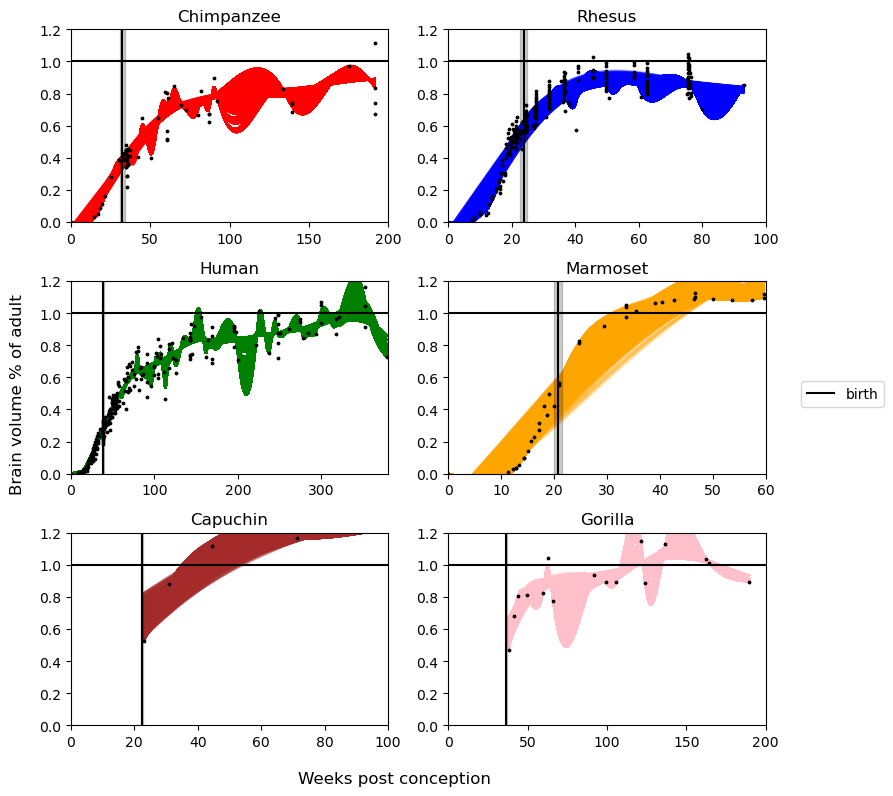

In [136]:
i = 0
fig, ax = plt.subplots(figsize = (8,8),nrows=3, ncols=2)

species_list = ["Chimpanzee","Rhesus","Human","Marmoset","Capuchin","Gorilla"]

for row in ax:
    for col in row:
        species = species_list[i]
        df_species = df[(df.Species == species)]
        sensitivity_df_species = sensitivity_df[(sensitivity_df.Species == species)]
        col.set_title(species)
        
        for index, row in sensitivity_df_species.iterrows():
            col.plot(row["x_values"], row["values"], '-', color = species_color[species],alpha = 0.2,zorder = 0)
        col.scatter(df_species[FIT_VARIABLE],df_species["Adult_percent_brain_volume_cm3"],color = "black", marker = 'o', s =3)

        col.axvline(x = gestation_periods_plot[species], color = "black",linestyle = '-',label="birth" if i == 0 else "")
        col.axvspan(gestation_periods[species] - gestation_periods_sd[species], gestation_periods[species] + gestation_periods_sd[species], alpha=0.2, color='black')

        col.axhline(y = 1, color = 'black')

        col.set_xlim(0,cut_period[species])
        col.set_ylim(0,1.2)
        i += 1


fig.supxlabel('Weeks post conception') 
fig.supylabel('Brain volume % of adult')
fig.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
#fig.savefig("{0}/figs/S1.pdf".format(PYTHON_PATH),dpi = 300)
plt.show()

(0.7, 1.0)

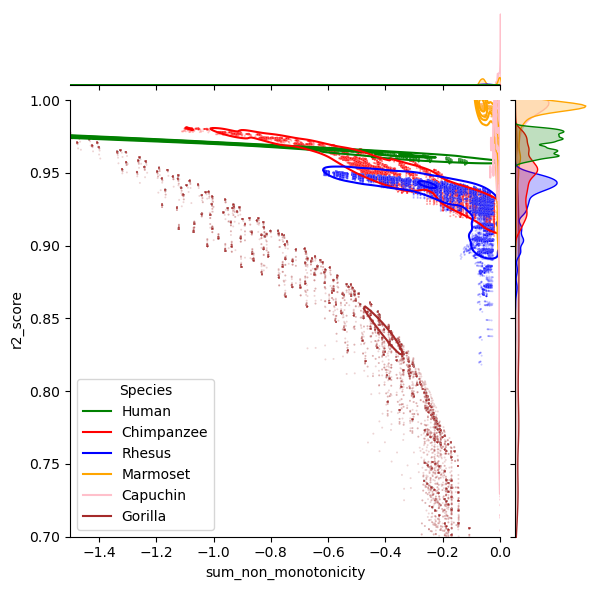

In [137]:
g = sns.jointplot(
    data=sensitivity_df,
    y="r2_score", x="sum_non_monotonicity", hue="Species",
    palette=["green","red","blue","orange","pink","brown"],alpha=.2,s=2)
g.plot_joint(sns.kdeplot,levels=5,common_norm=True)
#g.savefig("{0}/figs/S2.pdf".format(PYTHON_PATH),dpi = 100)
#g.savefig("{0}/figs/S2.eps".format(PYTHON_PATH),dpi = 100)
plt.xlim(-1.5,0)
plt.ylim(0.7,1)

Chimpanzee
Chimpanzee 5138
Rhesus
Rhesus 8910
Human
Human 7128
Marmoset
Marmoset 13488
Capuchin
Capuchin 15222
Gorilla
Gorilla 8794


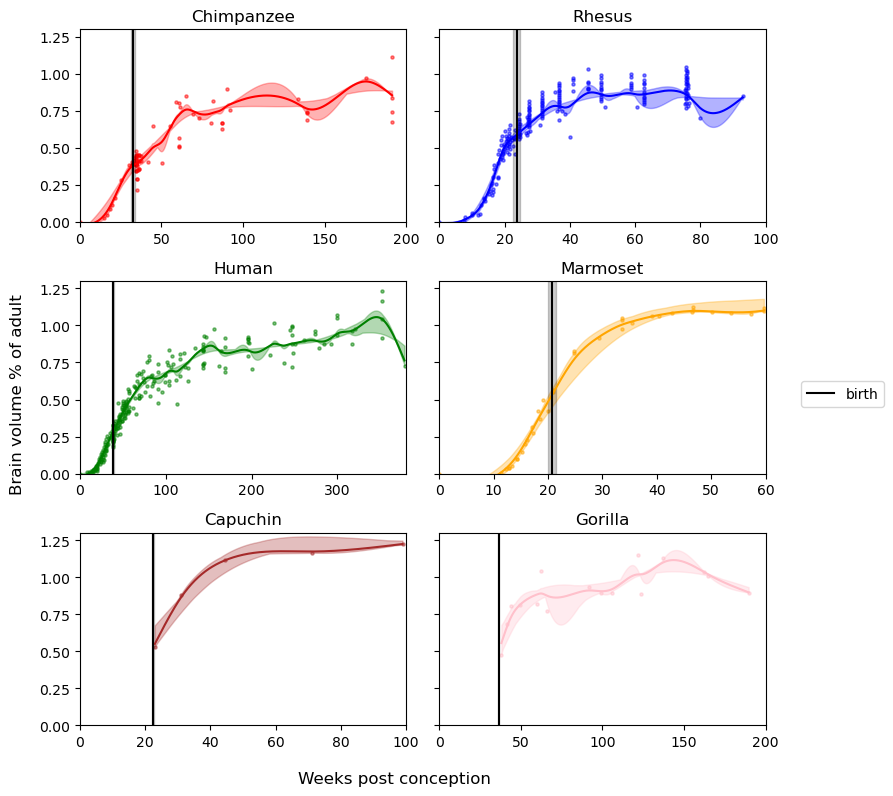

In [188]:
i = 0
average_fit,std_fit,max_fit,min_fit = {},{},{},{}
fig, ax = plt.subplots(nrows=3, ncols=2,figsize=(8, 8), sharey=True)
r2_species = {"Human": 0.93, "Chimpanzee":0.93, "Rhesus": 0.93, "Marmoset": 0.98, "Capuchin": 0.93, "Gorilla": 0.7}
nmono_species = {"Human": -0.8, "Chimpanzee":-0.4, "Rhesus": -0.4, "Marmoset": -0.2,"Capuchin": -0.4, "Gorilla": -0.5}

AVERAGE = "MEAN"
average_fit_list = [] 
all_derivatives_species= {}
all_derivatives_species_not_norm = {}
for row in ax:
    for col in row:
        species = species_list[i]
        print(species)
        df_species = df[(df.Species == species)]
        
        sensitivity_df_species = sensitivity_df[(sensitivity_df.Species == species) & (sensitivity_df.sum_non_monotonicity > nmono_species[species])
                                                & (sensitivity_df.r2_score > r2_species[species])]
        
        
        col.scatter(df_species[FIT_VARIABLE],df_species["Adult_percent_brain_volume_cm3"],color = species_color[species], marker = 'o', s =5,alpha =0.5)
        col.set_title(species)
        
        all_curves = []
        all_derivatives = []
        all_derivatives_not_norm = []

        for index, row in sensitivity_df_species.iterrows():
            curve = np.array(row["values"])
            x_values = np.array(row["x_values"])
            
            # Remove NaN values from curve and corresponding x_values
            mask = ~np.isnan(curve)
            curve = curve[mask]
            x_values = x_values[mask]

            # Skip if the curve becomes empty after removing NaNs
            if len(curve) == 0 or len(x_values) == 0:
                continue

            all_curves.append(curve)
            derivative = np.diff(curve) / np.diff(x_values)
            max_deriv = np.max(derivative) if np.max(derivative) != 0 else 1
            all_derivatives.append(derivative / max_deriv)
            all_derivatives_not_norm.append(derivative)

        x_to_predict_each_species[species] = x_values
        average_curve = np.mean(np.array(all_curves), axis=0)
        min_curve = np.min(np.array(all_curves), axis=0)
        max_curve = np.max(np.array(all_curves), axis=0)

        print(species, len(sensitivity_df_species))

        col.plot(x_to_predict_each_species[species], average_curve, '-', color = species_color[species],alpha = 1)
        col.fill_between(x_to_predict_each_species[species], min_curve,max_curve, color=species_color[species], alpha=0.3)

        all_derivatives_species[species] = all_derivatives
        all_derivatives_species_not_norm[species] = all_derivatives_not_norm
        col.axvline(x = gestation_periods_plot[species], color = "black",linestyle = '-',label="birth" if i == 0 else "")
        col.axvspan(gestation_periods[species] - gestation_periods_sd[species], gestation_periods[species] + gestation_periods_sd[species], alpha=0.2, color='black')

        col.set_xlim(0,cut_period[species])
        col.set_ylim(0,1.3)
        i += 1


fig.supxlabel('Weeks post conception') 
fig.supylabel('Brain volume % of adult')
fig.legend(loc='center left', bbox_to_anchor=(1, 0.5))
#fig.savefig("{0}/figs/S3.pdf".format(PYTHON_PATH),dpi = 300)
plt.tight_layout()
plt.show()

### Analysis of derivates lenght

In [189]:
all_species,all_derivatives, all_length_norm,all_length,all_percentiles = [],[],[],[],[]

mean_std = {}
for species in all_derivatives_species.keys():
    all_derivatives_length =[]
    percentiles = []
    for derivative in all_derivatives_species[species]:
        x = x_to_predict_each_species[species][:-1]
        y = derivative
        distance = 0
        for count in range(1,len(y)):
            distance += math.sqrt(math.pow(x[count]-x[count-1],2) + math.pow(y[count]-y[count-1],2))
        all_derivatives_length.append(distance)
    for value in all_derivatives_length:
        percentiles.append(stats.percentileofscore(all_derivatives_length, value,kind="strict"))

    all_percentiles.extend(percentiles)
    all_species.extend([species]*len(all_derivatives_length))
    all_length_norm.extend(all_derivatives_length/np.average(all_derivatives_length))
    mean_std[species] = {"mean":np.mean(all_derivatives_length),"std":np.std(all_derivatives_length),"median":np.median(all_derivatives_length)}
    all_length.extend(all_derivatives_length)
    all_derivatives.extend(all_derivatives_species[species])

derivatives_df = pd.DataFrame({"species":all_species,"derivatives":all_derivatives,
                               "length":all_length,"length_norm":all_length_norm,
                               "percentile":all_percentiles})

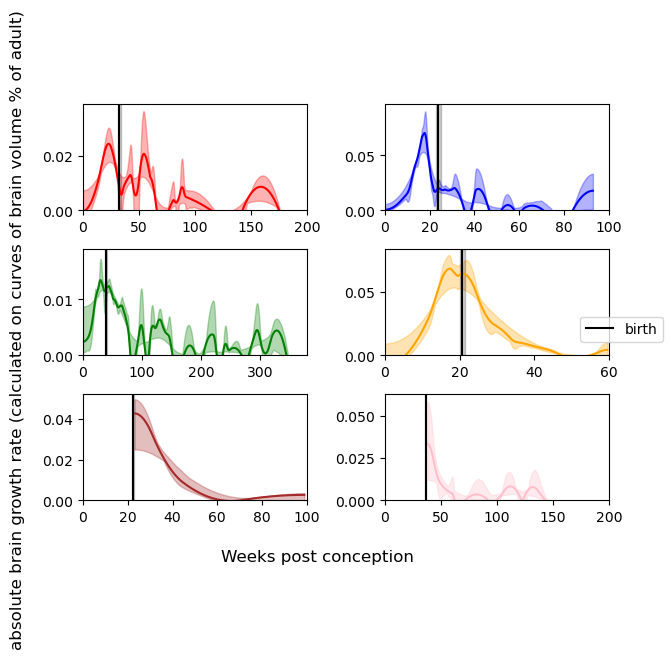

In [190]:
i = 0
derivative_data_species = {}
average_derivative = []
fig, ax = plt.subplots(nrows=3, ncols=2)

for row in ax:
    for col in row:
        species= species_list[i]
        all_devs = all_derivatives_species_not_norm[species]

        average_derivative = np.mean(np.array(all_devs), axis=0)
        percentile2_5_derivative = np.percentile(np.array(all_devs),q = 2.5, axis=0)
        percentile97_5derivative = np.percentile(np.array(all_devs),q = 97.5, axis=0)

        low_95Percentil = gaussian_filter1d(percentile2_5_derivative,sigma = 1)
        max_95Percentil = gaussian_filter1d(percentile97_5derivative,sigma = 1)

        col.fill_between(x_to_predict_each_species[species][:-1], low_95Percentil,max_95Percentil, color=species_color[species], alpha=0.3)

        col.plot(x_to_predict_each_species[species][:-1], average_derivative, '-', color = species_color[species],alpha = 1)
        col.axvline(x = gestation_periods_plot[species], color = "black",linestyle = '-',label="birth" if i == 0 else "")
        col.axvspan(gestation_periods[species] - gestation_periods_sd[species], gestation_periods[species] + gestation_periods_sd[species], alpha=0.2, color='black')
        col.set_ylim(bottom=0)
        col.set_xlim(0,cut_period[species])

        i += 1

fig.supxlabel('Weeks post conception') 
fig.supylabel('absolute brain growth rate (calculated on curves of brain volume % of adult)')
fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))
fig.tight_layout()
fig.savefig("{0}/figs/absolute_brain_growth_6_species_sensitivity_analysis.pdf".format(PYTHON_PATH),dpi = 300)
plt.show()

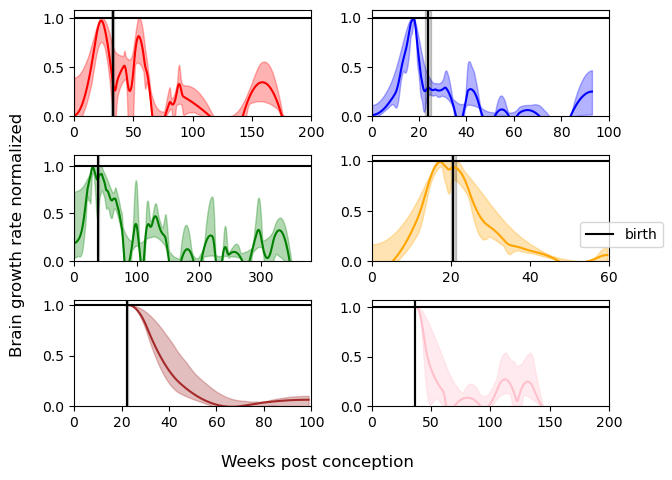

In [191]:
i = 0
derivative_data_species = {}
average_derivative = []
fig, ax = plt.subplots(nrows=3, ncols=2)

for row in ax:
    for col in row:
        species= species_list[i]
        all_devs = list(derivatives_df[derivatives_df.species == species]["derivatives"])

        average_derivative = np.mean(np.array(all_devs), axis=0)
        percentile2_5_derivative = np.percentile(np.array(all_devs),q = 2.5, axis=0)
        percentile97_5derivative = np.percentile(np.array(all_devs),q = 97.5, axis=0)

        low_95Percentil = gaussian_filter1d(percentile2_5_derivative,sigma = 1)
        max_95Percentil = gaussian_filter1d(percentile97_5derivative,sigma = 1)

        col.fill_between(x_to_predict_each_species[species][:-1], low_95Percentil,max_95Percentil, color=species_color[species], alpha=0.3)

        col.plot(x_to_predict_each_species[species][:-1], average_derivative, '-', color = species_color[species],alpha = 1)
        col.axvline(x = gestation_periods_plot[species], color = "black",linestyle = '-',label="birth" if i == 0 else "")
        col.axvspan(gestation_periods[species] - gestation_periods_sd[species], gestation_periods[species] + gestation_periods_sd[species], alpha=0.2, color='black')
        col.axhline(y = 1, color = 'black')
        col.set_ylim(bottom=0)
        col.set_xlim(0,cut_period[species])

        i += 1

fig.supxlabel('Weeks post conception') 
fig.supylabel('Brain growth rate normalized')
fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))
fig.tight_layout()
#fig.savefig("{0}/figs/S4.pdf".format(PYTHON_PATH),dpi = 300)
plt.show()

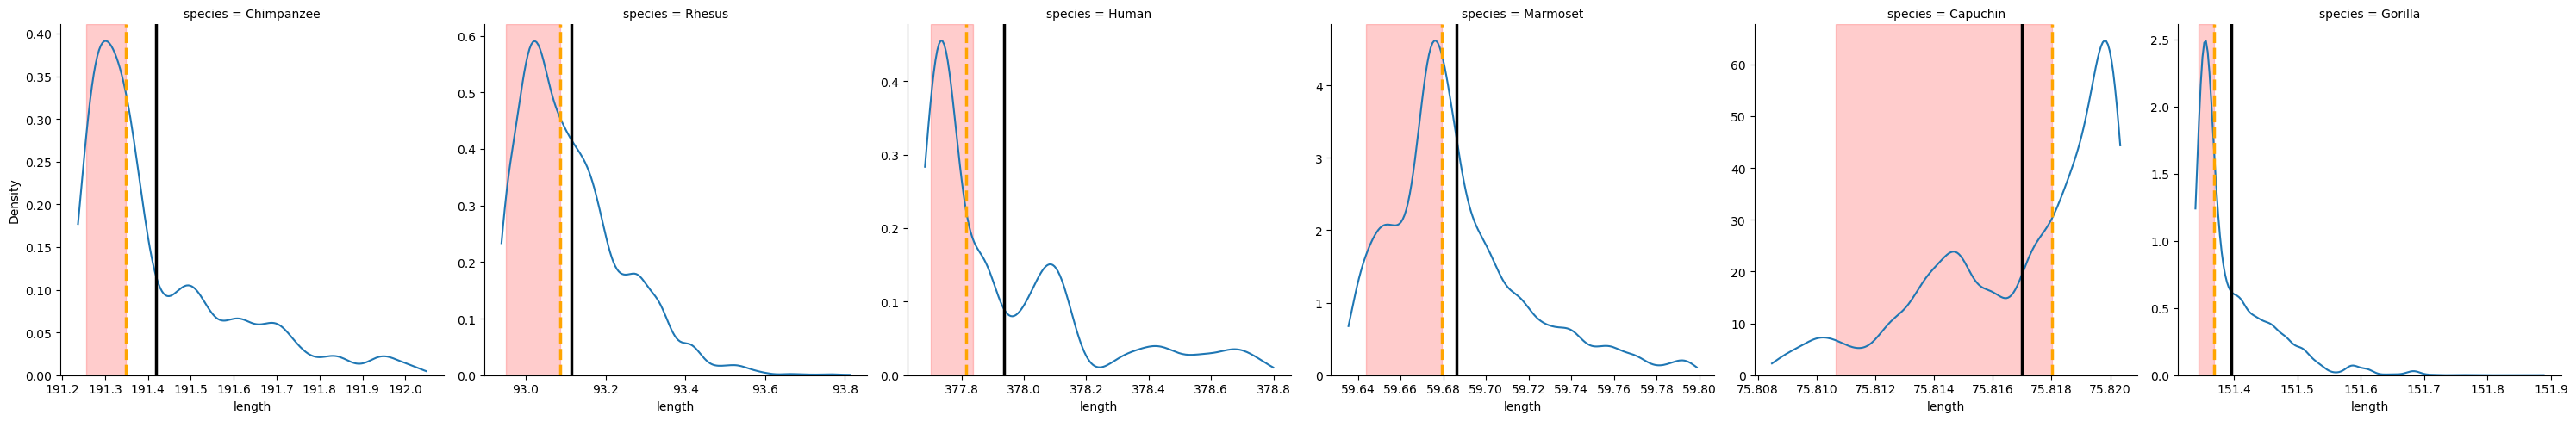

In [195]:
g = sns.displot(data=derivatives_df, x="length", col="species",cut = 0, kind="kde",facet_kws=dict(sharey=False,sharex=False))
axes = g.axes.flatten()

general_min = 5
general_max = 50
MIN_PERCENTIL_species= {"Human": general_min, "Chimpanzee":general_min, "Rhesus": general_min, "Marmoset": general_min,"Capuchin": general_min, "Gorilla": general_min}
MAX_PERCENTIL_species= {"Human": general_max, "Chimpanzee":general_max, "Rhesus": general_max, "Marmoset": general_max,"Capuchin": general_max, "Gorilla": general_max}

for ax in axes:
    # extract the species name
    spec = ax.get_title().split(' = ')[1]
    ax.axvline(x=mean_std[spec]['mean'], c='k', ls='-', lw=2.5)
    ax.axvline(x=mean_std[spec]['median'], c='orange', ls='--', lw=2.5)
    ax.axvspan(derivatives_df[(derivatives_df.species == spec)&(derivatives_df.percentile >= MIN_PERCENTIL_species[spec])]["length"].min(),
                derivatives_df[(derivatives_df.species == spec)&(derivatives_df.percentile <= MAX_PERCENTIL_species[spec])]["length"].max(), alpha=0.2, color='red')


#g.savefig("{0}/figs/S5.pdf".format(PYTHON_PATH),dpi = 500)


## Definig derivative filters

In [196]:
derivatives_df_FILTERED = pd.DataFrame({"species":[],"derivatives":[],"length":[],"length_norm":[],"percentile":[]})

for species in derivatives_df["species"].unique():
    species_df = derivatives_df[
        (derivatives_df.percentile >= MIN_PERCENTIL_species[species])
        & (derivatives_df.percentile <= MAX_PERCENTIL_species[species])
        & (derivatives_df.species == species)
    ]
    derivatives_df_FILTERED = pd.concat([derivatives_df_FILTERED, species_df], ignore_index=True)

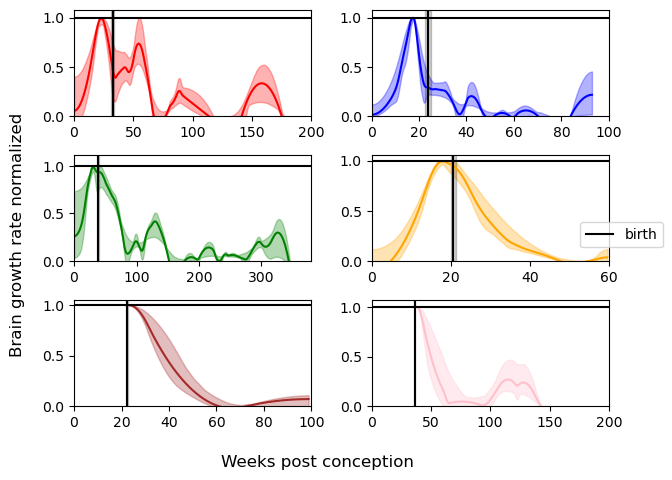

<Figure size 3000x5000 with 0 Axes>

In [197]:
i = 0
derivative_data_species = {}
average_derivative = []
fig, ax = plt.subplots(nrows=3, ncols=2)
plt.figure(figsize=(6, 10), dpi=500)
df_plot = {"species":[],"N":[],"x_dydx":[],"y_dydx":[],"y_dydx_low_95Percentil":[],"y_dydx_max_95Percentil":[],"all_y":[]}

for row in ax:
    for col in row:
        species= species_list[i]

        all_devs = np.array(list(derivatives_df_FILTERED[derivatives_df_FILTERED.species == species]["derivatives"]))

        average_derivative = np.mean(all_devs, axis=0)
        percentile2_5_derivative = np.percentile(all_devs,q = 2.5, axis=0)
        percentile97_5derivative = np.percentile(all_devs,q = 97.5, axis=0)

        low_95Percentil = gaussian_filter1d(percentile2_5_derivative,sigma = 1)
        max_95Percentil = gaussian_filter1d(percentile97_5derivative,sigma = 1)

        col.fill_between(x_to_predict_each_species[species][:-1], low_95Percentil,max_95Percentil, color=species_color[species], alpha=0.3)

        col.plot(x_to_predict_each_species[species][:-1], average_derivative, '-', color = species_color[species],alpha = 1)
        col.axvline(x = gestation_periods_plot[species], color = "black",linestyle = '-',label="birth" if i == 0 else "")
        col.axvspan(gestation_periods[species] - gestation_periods_sd[species], gestation_periods[species] + gestation_periods_sd[species], alpha=0.2, color='black')
        col.axhline(y = 1, color = 'black')
        col.set_ylim(bottom=0)
        col.set_xlim(0,cut_period[species])

        df_plot["species"].append(species)
        df_plot["N"].append(len(all_devs))
        df_plot["x_dydx"].append(x_to_predict_each_species[species][:-1])
        df_plot["y_dydx"].append(average_derivative)
        df_plot["y_dydx_low_95Percentil"].append(low_95Percentil)
        df_plot["y_dydx_max_95Percentil"].append(max_95Percentil)
        df_plot["all_y"].append(np.array(all_devs))
        i += 1

df_plot = pd.DataFrame(df_plot)
df_plot.to_pickle("{0}/data/derivatives_with_error.pkl".format(PYTHON_PATH)) 

fig.supxlabel('Weeks post conception') 
fig.supylabel('Brain growth rate normalized')
fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))
#fig.savefig("{0}/figs/S6.pdf".format(PYTHON_PATH),dpi = 300)
fig.tight_layout()
plt.show()